In [ ]:
w=10
x=2
y=5

def f(w,x,y):
    return w*x-y
f(w,x,y)

15

In [ ]:
w=w-0.1*x
f(w,x,y)

14.600000000000001

In [ ]:
import numpy as np

def f(w,x,y):
    return 0.5*(w*x-y)**2
def gradient(w,x,y):
    return (w*x-y)*x

w=10
x=2
y=5
alpha=0.1
losses=[]
for i in range(100):
    loss = f(w,x,y)
    grad =gradient(w,x,y)
    w=w-alpha*grad
    losses.append(loss)
    print(f"iterations: {i}, weght: {w:.4f}, loss: {loss:.4f}, grad: {grad:.4f}")

iterations: 0, weght: 7.0000, loss: 112.5000, grad: 30.0000
iterations: 1, weght: 5.2000, loss: 40.5000, grad: 18.0000
iterations: 2, weght: 4.1200, loss: 14.5800, grad: 10.8000
iterations: 3, weght: 3.4720, loss: 5.2488, grad: 6.4800
iterations: 4, weght: 3.0832, loss: 1.8896, grad: 3.8880
iterations: 5, weght: 2.8499, loss: 0.6802, grad: 2.3328
iterations: 6, weght: 2.7100, loss: 0.2449, grad: 1.3997
iterations: 7, weght: 2.6260, loss: 0.0882, grad: 0.8398
iterations: 8, weght: 2.5756, loss: 0.0317, grad: 0.5039
iterations: 9, weght: 2.5453, loss: 0.0114, grad: 0.3023
iterations: 10, weght: 2.5272, loss: 0.0041, grad: 0.1814
iterations: 11, weght: 2.5163, loss: 0.0015, grad: 0.1088
iterations: 12, weght: 2.5098, loss: 0.0005, grad: 0.0653
iterations: 13, weght: 2.5059, loss: 0.0002, grad: 0.0392
iterations: 14, weght: 2.5035, loss: 0.0001, grad: 0.0235
iterations: 15, weght: 2.5021, loss: 0.0000, grad: 0.0141
iterations: 16, weght: 2.5013, loss: 0.0000, grad: 0.0085
iterations: 17, w

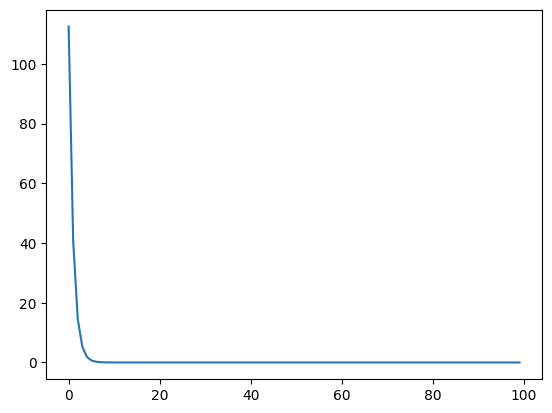

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses);

In [ ]:
X = np.arange(0,100,2)


In [ ]:
X

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32,
       34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66,
       68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98])

In [ ]:
import numpy as np

np.random.seed(42)
m=100
X=2*np.random.rand(m,1) #column vector
y= 4+ 3*X +np.random.randn(m,1)

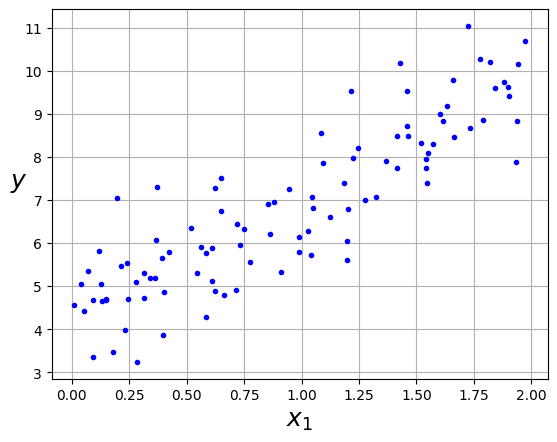

In [ ]:
plt.plot(X,y,'b.')
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.grid()
plt.show()

In [ ]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
X_b[:5]

array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788],
       [1.        , 1.19731697],
       [1.        , 0.31203728]])

In [ ]:
X[:5]

array([[0.74908024],
       [1.90142861],
       [1.46398788],
       [1.19731697],
       [0.31203728]])

In [ ]:
theta_best = np.linalg.inv(X_b.T @ X_b) @ (X_b.T @ y)
theta_best

array([[4.21509616],
       [2.77011339]])

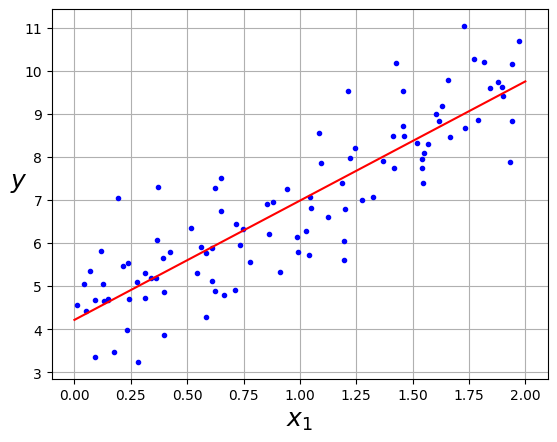

In [ ]:
X_new=np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_pred = X_new_b @ theta_best

plt.plot(X,y, 'b.')
plt.plot(X_new, y_pred, 'r-')
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("$y$",rotation=0,fontsize=18)
plt.grid()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg=LinearRegression()
lin_reg.fit(X,y)
lin_reg.coef_, lin_reg.intercept_

(array([[2.77011339]]), array([4.21509616]))

# Batch Gradient Descent

In [ ]:
np.random.seed(42)
eta=0.1 #learning rate
n_epochs=1000
m=len(X_b)
theta = np.random.randn(2,1) # randomly selected parameters

for i in range(n_epochs):
    gradients=(1/m)*(X_b.T @ (X_b @ theta - y))
    theta = theta - eta * gradients
print(theta)

[[4.21509613]
 [2.77011341]]


#Stochastic Gradient Descent

In [ ]:
n_epochs=50
theta = np.random.rand(2,1)
for epoch in range (n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi=X_b[random_index:random_index+1]
        yi=y[random_index:random_index+1]
        gradients=xi.T @ (xi @ theta - yi)
        theta = theta - eta *gradients
print(theta)

[[3.99874928]
 [2.4448152 ]]


In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=0.001, n_iter_no_change = 20)
sgd_reg.fit(X,y.ravel())
sgd_reg.intercept_,sgd_reg.coef_

(array([3.96848366]), array([2.98768065]))

# Mini Batch Gradient Descent

In [ ]:
n_epochs=50
batch_size=32
theta = np.random.rand(2,1)
for epoch in range (n_epochs):
    for i in range(batch_size):
        random_index = np.random.randint(batch_size)
        xi=X_b[random_index:random_index+1]
        yi=y[random_index:random_index+1]
        gradients=xi.T @ (xi @ theta - yi) / batch_size
        theta = theta - eta * gradients
print(theta)

[[3.91092731]
 [2.91933858]]


# Polynomial Features

In [ ]:
np.random.seed(42)
m=100
X=6* np.random.rand(m,1)-3
y=0.5 * X ** 2 + X + 2 + np.random.randn(m,1)

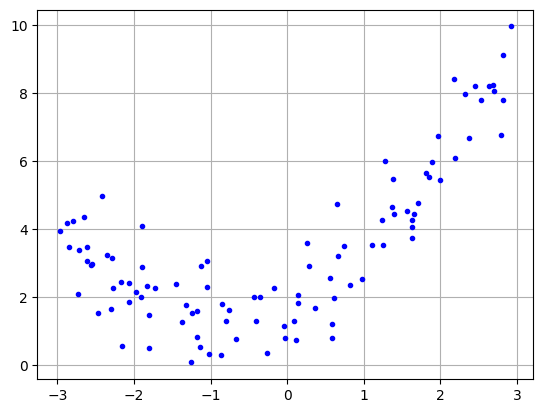

In [ ]:
plt.plot(X,y,'b.')
plt.grid()

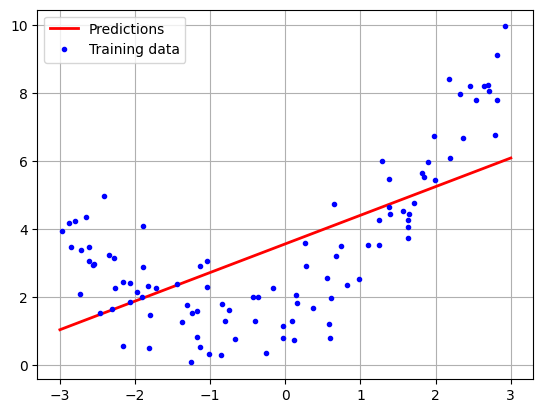

In [ ]:
lin_reg.fit(X,y)
X_new = np.linspace(-3,3,100).reshape(100,1)
y_predicts=lin_reg.predict(X_new)

plt.plot(X_new,y_predicts, 'r-',linewidth=2,label='Predictions')
plt.plot(X,y,'b.',label='Training data')
plt.legend()
plt.grid();

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

poly=PolynomialFeatures(degree=2, include_bias=False)
X_poly=poly.fit_transform(X)
X[0]

array([-0.75275929])

In [ ]:
X_poly[0]

array([-0.75275929,  0.56664654])

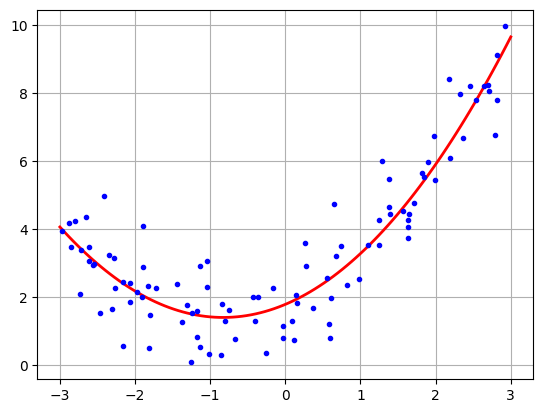

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)
X_new_poly=poly.transform(X_new)
y_predict=lin_reg.predict(X_new_poly)

plt.plot(X_new, y_predict, "r-", linewidth=2,label="Predictions")
plt.plot(X,y,"b.",label="Training data")
plt.grid()
plt.show()

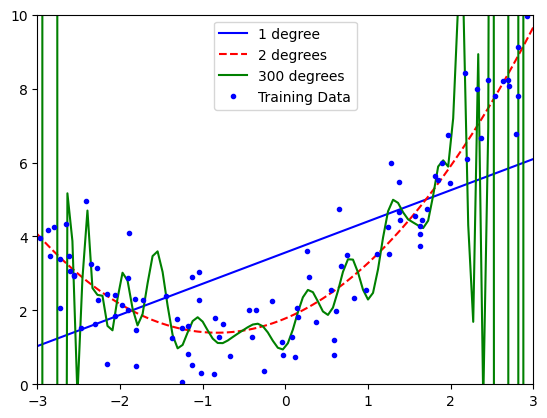

In [ ]:
for degree, style in ((1,'b-'),(2,'r--'),(300,'g-')):
    poly=PolynomialFeatures(degree=degree,include_bias=False)
    lin_reg=LinearRegression()
    std_scaler=StandardScaler()
    polynomial_reg=make_pipeline(poly,std_scaler,lin_reg)
    polynomial_reg.fit(X,y)
    y_predict=polynomial_reg.predict(X_new)
    label=f"{degree} degree"+('s' if degree>1 else '')
    plt.plot(X_new,y_predict,style,label=label)
    plt.axis([-3,3,0,10])
plt.plot(X,y,"b.",label="Training Data")
plt.legend();

# Ridge

In [ ]:
from sklearn.linear_model import Ridge #L2

ridge_reg=Ridge(alpha=1,random_state=42)
ridge_reg.fit(X,y)

Ridge(alpha=1, random_state=42)

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_reg=SGDRegressor(random_state=42,penalty='l2')

# Lasso

In [ ]:
from sklearn.linear_model import Lasso #l1

lasso_reg=Lasso(alpha=0.1)
lasso_reg.fit(X,y)

Lasso(alpha=0.1)

# ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet

elastic_net=ElasticNet(alpha=0.1,l1_ratio=0.4,random_state=42)
elastic_net.fit(X,y)

ElasticNet(alpha=0.1, l1_ratio=0.4, random_state=42)

# Logistic Regression

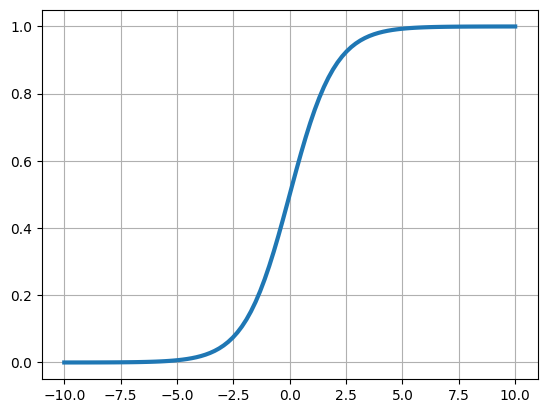

In [ ]:
z=np.linspace(-10,10,100)
sigmoid=1/(1+np.exp(-z))

plt.plot(z,sigmoid,linewidth=3)
plt.grid()
plt.show();

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

iris=load_iris(as_frame=True)

X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2,random_state=42)

log_reg=LogisticRegression(random_state=42)
log_reg.fit(X_train,y_train)
log_reg.score(X_test,y_test)

1.0

In [ ]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


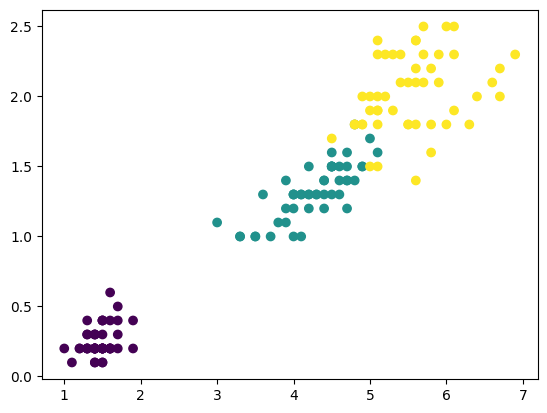

In [ ]:
plt.scatter(X['petal length (cm)'],X['petal width (cm)'], c=y)